# Установка зависимостей

In [ ]:
!pip install pandas numpy matplotlib scikit-learn tensorflow

# Импорт

In [28]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras import optimizers
import matplotlib.pyplot as plt
import numpy as np

# Загрузка данных

In [29]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
print("Размер обучающей выборки:", train_images.shape)
print("Размер тестовой выборки:", test_images.shape)

Размер обучающей выборки: (60000, 28, 28)
Размер тестовой выборки: (10000, 28, 28)


# Предобработка данных

In [30]:
# Нормализация
train_images = train_images / 255.0
test_images = test_images / 255.0

# One-hot кодирование меток
train_labels_cat = to_categorical(train_labels, 10)
test_labels_cat = to_categorical(test_labels, 10)

# Генерация модели

In [31]:
def create_model():
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(256, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

In [32]:
def train_and_evaluate(optimizer, epochs=5, batch_size=128):
    model = create_model()
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(train_images, train_labels_cat,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(test_images, test_labels_cat),
                        verbose=0)

    test_loss, test_acc = model.evaluate(test_images, test_labels_cat, verbose=0)
    return history, test_acc

# Исследование различных параметров оптимизаторов

In [58]:
def plot_optimizer_accuracy(optimizer_results, title):
  plt.figure(figsize=(10,5))
  bars = plt.bar(optimizer_results.keys(), optimizer_results.values(), color='lightgreen')
  plt.xticks(rotation=45, ha='right')
  plt.ylabel('Test Accuracy')
  plt.title(title)
  min_val = min(optimizer_results.values())
  max_val = 1.0
  delta = 0.05
  plt.ylim(min_val-delta, 1.0)
  plt.grid(axis='y')
  for bar in bars:
      height = bar.get_height()
      plt.text(bar.get_x() + bar.get_width()/2., height,
              f'{height:.3f}', ha='center', va='bottom')
  plt.tight_layout()
  plt.show()

## SGD

In [61]:
sgd_results = {}
sgd_histories = {}

# Базовый SGD (lr=0.01)
base_sgd = optimizers.SGD(learning_rate=0.01)
hist_base, acc_base = train_and_evaluate(base_sgd)
sgd_results['SGD (default lr=0.01)'] = acc_base
sgd_histories['SGD (default lr=0.01)'] = hist_base
print(f"\nSGD (default lr=0.01): {acc_base:.4f}")

# 1. Варьируем learning rate
lr_list = [0.1, 0.01, 0.001, 0.0001]
for lr in lr_list:
    name = f'SGD (lr={lr})'
    opt = optimizers.SGD(learning_rate=lr)
    hist, acc = train_and_evaluate(opt)
    sgd_results[name] = acc
    sgd_histories[name] = hist
    print(f"{name}: {acc:.4f}")

# 2. Варьируем momentum (при фиксированном lr=0.01)
mom_list = [0.0, 0.5, 0.9, 0.99]
for mom in mom_list:
    name = f'SGD (mom={mom})'
    opt = optimizers.SGD(learning_rate=0.01, momentum=mom)
    hist, acc = train_and_evaluate(opt)
    sgd_results[name] = acc
    sgd_histories[name] = hist
    print(f"{name}: {acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



SGD (default lr=0.01): 0.9119
SGD (lr=0.1): 0.9602
SGD (lr=0.01): 0.9108
SGD (lr=0.001): 0.8252
SGD (lr=0.0001): 0.2581
SGD (mom=0.0): 0.9088
SGD (mom=0.5): 0.9260
SGD (mom=0.9): 0.9594
SGD (mom=0.99): 0.9787


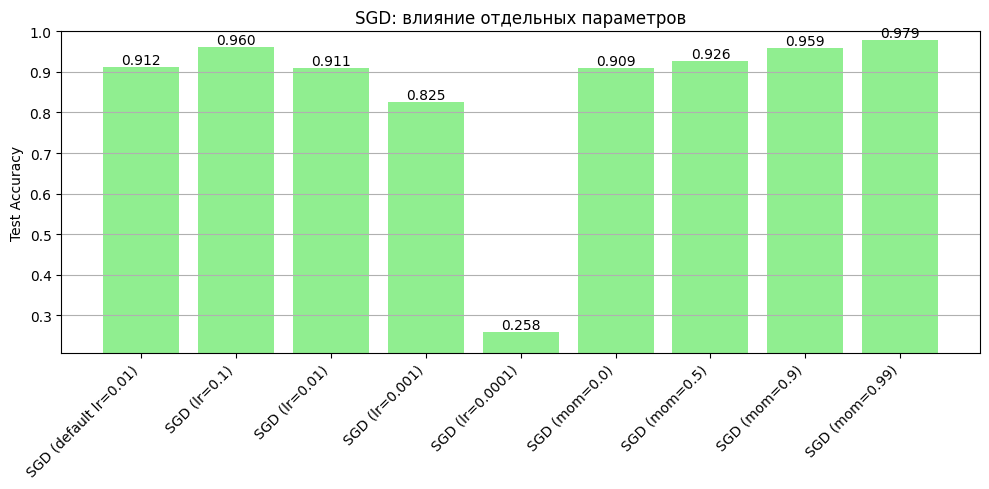

In [62]:
plot_optimizer_accuracy(sgd_results, "SGD: влияние отдельных параметров")

## Adam


In [63]:
adam_results = {}
adam_histories = {}

# Базовый Adam
base_adam = optimizers.Adam()
hist_base, acc_base = train_and_evaluate(base_adam)
adam_results['Adam (default)'] = acc_base
adam_histories['Adam (default)'] = hist_base
print(f"\nAdam (default): {acc_base:.4f}")

# 1. Варьируем learning rate
lr_list = [0.1, 0.01, 0.001, 0.0001]
for lr in lr_list:
    name = f'Adam (lr={lr})'
    opt = optimizers.Adam(learning_rate=lr)
    hist, acc = train_and_evaluate(opt)
    adam_results[name] = acc
    adam_histories[name] = hist
    print(f"{name}: {acc:.4f}")

# 2. Варьируем beta_1
beta1_list = [0.8, 0.9, 0.95, 0.99]
for b1 in beta1_list:
    name = f'Adam (beta1={b1})'
    opt = optimizers.Adam(beta_1=b1)
    hist, acc = train_and_evaluate(opt)
    adam_results[name] = acc
    adam_histories[name] = hist
    print(f"{name}: {acc:.4f}")

# 3. Варьируем beta_2
beta2_list = [0.9, 0.99, 0.999, 0.9999]
for b2 in beta2_list:
    name = f'Adam (beta2={b2})'
    opt = optimizers.Adam(beta_2=b2)
    hist, acc = train_and_evaluate(opt)
    adam_results[name] = acc
    adam_histories[name] = hist
    print(f"{name}: {acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Adam (default): 0.9763
Adam (lr=0.1): 0.8604
Adam (lr=0.01): 0.9632
Adam (lr=0.001): 0.9780
Adam (lr=0.0001): 0.9453
Adam (beta1=0.8): 0.9785
Adam (beta1=0.9): 0.9765
Adam (beta1=0.95): 0.9768
Adam (beta1=0.99): 0.9769
Adam (beta2=0.9): 0.9752
Adam (beta2=0.99): 0.9771
Adam (beta2=0.999): 0.9742
Adam (beta2=0.9999): 0.9768


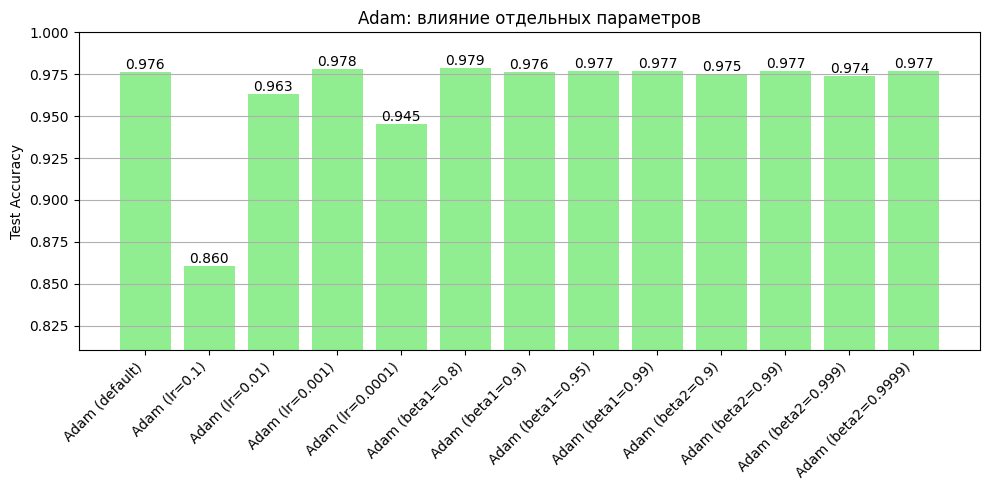

In [64]:
plot_optimizer_accuracy(adam_results, "Adam: влияние отдельных параметров")

## RMSprop

In [65]:
rms_results = {}
rms_histories = {}

# Базовый RMSprop (lr=0.001)
base_rms = optimizers.RMSprop()
hist_base, acc_base = train_and_evaluate(base_rms)
rms_results['RMSprop (default)'] = acc_base
rms_histories['RMSprop (default)'] = hist_base
print(f"\nRMSprop (default): {acc_base:.4f}")

# 1. Варьируем learning rate
lr_list = [0.1, 0.01, 0.001, 0.0001]
for lr in lr_list:
    name = f'RMSprop (lr={lr})'
    opt = optimizers.RMSprop(learning_rate=lr)
    hist, acc = train_and_evaluate(opt)
    rms_results[name] = acc
    rms_histories[name] = hist
    print(f"{name}: {acc:.4f}")

# 2. Варьируем rho
rho_list = [0.9, 0.95, 0.99]
for rho in rho_list:
    name = f'RMSprop (rho={rho})'
    opt = optimizers.RMSprop(rho=rho)
    hist, acc = train_and_evaluate(opt)
    rms_results[name] = acc
    rms_histories[name] = hist
    print(f"{name}: {acc:.4f}")

# 3. Варьируем momentum
mom_list = [0.0, 0.5, 0.9]
for mom in mom_list:
    name = f'RMSprop (mom={mom})'
    opt = optimizers.RMSprop(momentum=mom)
    hist, acc = train_and_evaluate(opt)
    rms_results[name] = acc
    rms_histories[name] = hist
    print(f"{name}: {acc:.4f}")


RMSprop (default): 0.9782
RMSprop (lr=0.1): 0.8532
RMSprop (lr=0.01): 0.9716
RMSprop (lr=0.001): 0.9778
RMSprop (lr=0.0001): 0.9418
RMSprop (rho=0.9): 0.9751
RMSprop (rho=0.95): 0.9778
RMSprop (rho=0.99): 0.9773
RMSprop (mom=0.0): 0.9787
RMSprop (mom=0.5): 0.9793
RMSprop (mom=0.9): 0.9758


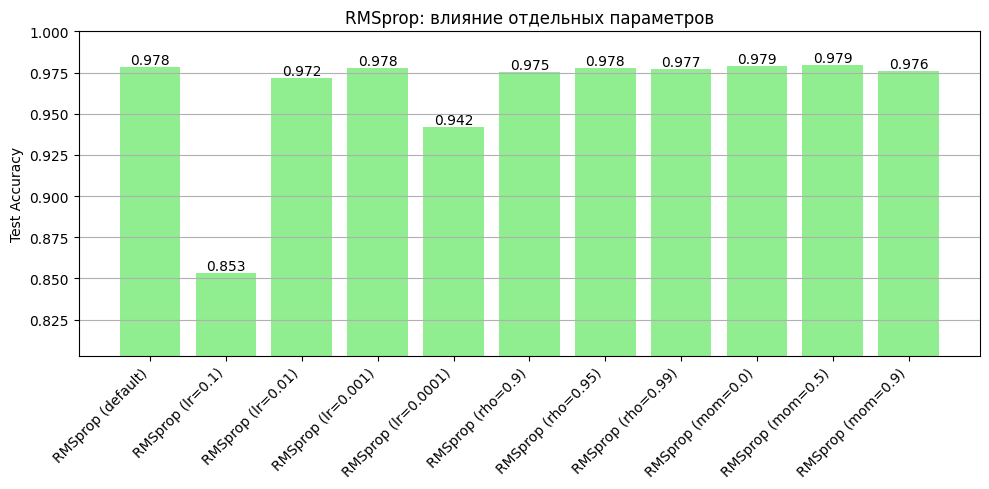

In [67]:
plot_optimizer_accuracy(rms_results, "RMSprop: влияние отдельных параметров")

# Исследование различных оптимизаторов

In [68]:
def plot_loss(histories, names=None, figsize=(10, 6)):
    plt.figure(figsize=figsize)

    if names is None:
        names = list(histories.keys())

    colors = plt.cm.tab10(np.linspace(0, 1, len(names)))

    for idx, name in enumerate(names):
        hist = histories[name]
        color = colors[idx]
        plt.plot(hist.history['loss'], label=f'{name} (train)', color=color)
        plt.plot(hist.history['val_loss'], '--', label=f'{name} (val)', color=color)

    plt.xlabel('Эпоха')
    plt.ylabel('Потери (Loss)')
    plt.title('Динамика потерь на обучении и валидации')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_accuracy(histories, names=None, figsize=(10, 6)):
    plt.figure(figsize=figsize)

    if names is None:
        names = list(histories.keys())

    colors = plt.cm.tab10(np.linspace(0, 1, len(names)))

    for idx, name in enumerate(names):
        hist = histories[name]
        color = colors[idx]
        plt.plot(hist.history['accuracy'], label=f'{name} (train)', color=color)
        plt.plot(hist.history['val_accuracy'], '--', label=f'{name} (val)', color=color)

    plt.xlabel('Эпоха')
    plt.ylabel('Точность (Accuracy)')
    plt.title('Динамика точности на обучении и валидации')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [71]:
optimizers_list = {
    'SGD': optimizers.SGD(learning_rate=0.1, momentum=0.99),
    'Adam': optimizers.Adam(learning_rate=0.001, beta_1=0.8),
    'RMSprop': optimizers.RMSprop(learning_rate=0.001, rho=0.95, momentum=0.5),
}

results = {}
histories = {}

for name, opt in optimizers_list.items():
    print(f"Обучение с {name}")
    hist, acc = train_and_evaluate(opt)
    results[name] = acc
    histories[name] = hist
    print(f"Точность на тесте: {acc:.4f}\n")

Обучение с SGD (lr=0.1, momentum=0.99)
Точность на тесте: 0.8246

Обучение с Adam (lr=0.001, beta_1=0.8)
Точность на тесте: 0.9774

Обучение с RMSprop (lr=0.001, rho=0.95, momentum=0.5)
Точность на тесте: 0.9800



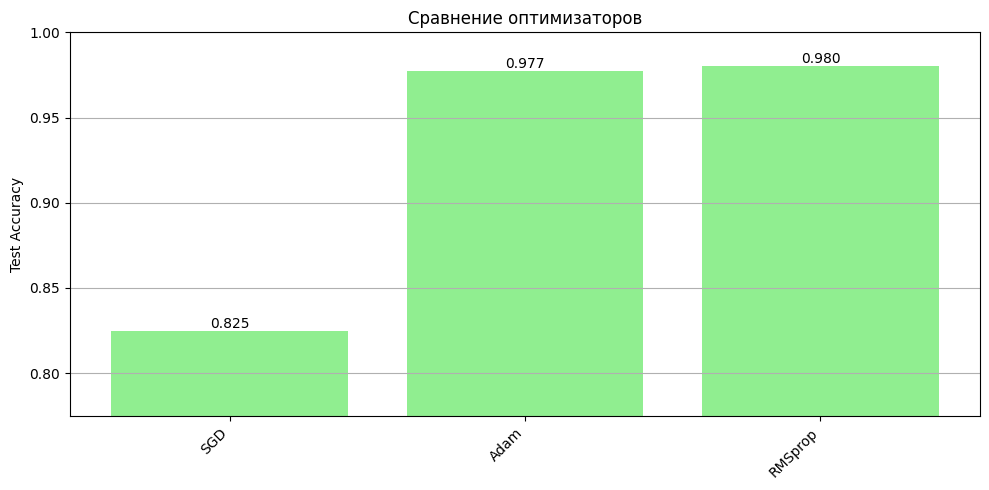

In [73]:
plot_optimizer_accuracy(results, "Сравнение оптимизаторов")

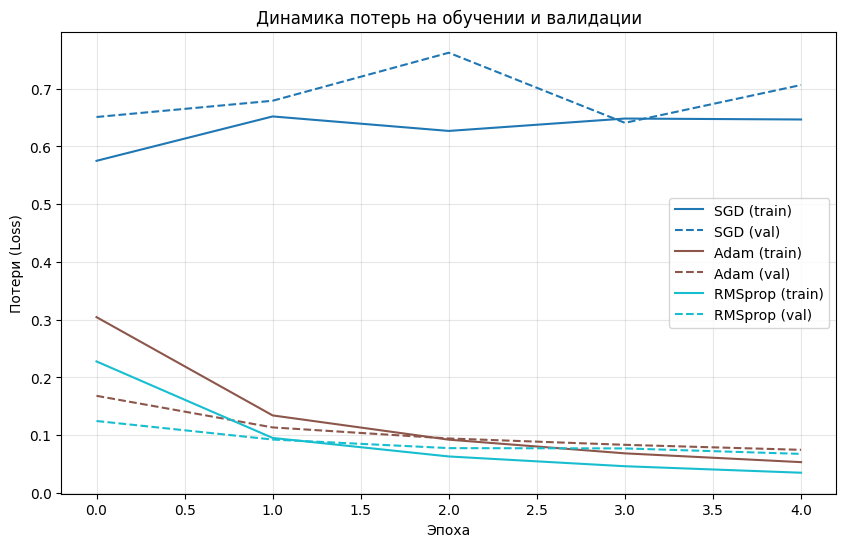

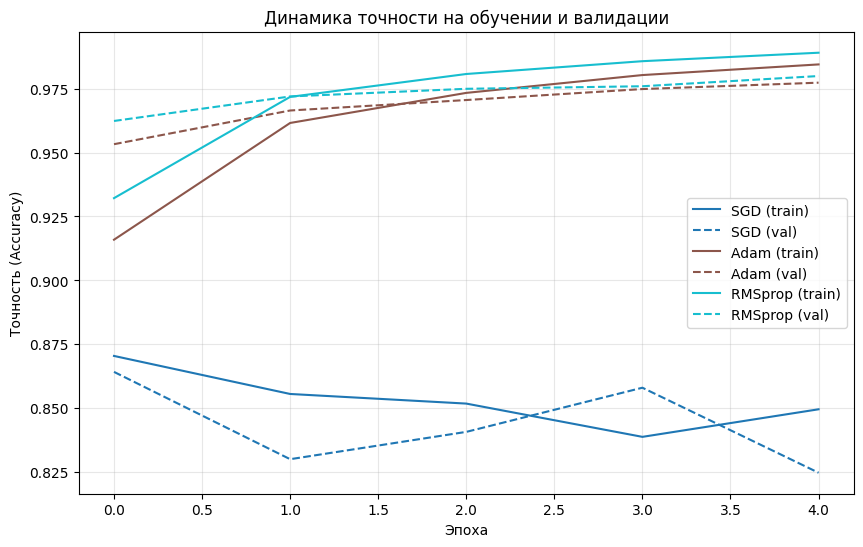

In [78]:
plot_loss(histories, names=list(histories.keys()))
plot_accuracy(histories, names=list(histories.keys()))

# Обработка пользовательского изображения

In [79]:
from google.colab import files
from PIL import Image
import io

In [80]:
def load_and_preprocess_image(image_path, invert=True):
    """Загружает изображение, подготавливает его для модели MNIST."""
    img = Image.open(image_path).convert('L')  # в градации серого
    img = img.resize((28, 28))
    img_array = np.array(img, dtype=np.float32)

    if invert:
        img_array = 255 - img_array

    img_array = img_array / 255.0

    img_array = np.expand_dims(img_array, axis=0)
    return img_array

In [81]:
def predict_user_image(model, image_path, invert):
    processed = load_and_preprocess_image(image_path, invert=invert)
    prediction = model.predict(processed)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction)
    return predicted_class, confidence

In [93]:
final_model = create_model()
final_optimizer = optimizers.RMSprop(learning_rate=0.001, rho=0.95, momentum=0.5)
final_model.compile(optimizer=final_optimizer,
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])
final_model.fit(train_images, train_labels_cat, epochs=5, batch_size=128, verbose=1)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8896 - loss: 0.3727
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9703 - loss: 0.1020
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9807 - loss: 0.0645
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9869 - loss: 0.0431
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9900 - loss: 0.0329


Saving Screenshot from 2026-03-11 12-50-53.png to Screenshot from 2026-03-11 12-50-53 (8).png
Загружен файл: Screenshot from 2026-03-11 12-50-53 (8).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Предсказанная цифра: 5, уверенность: 0.70


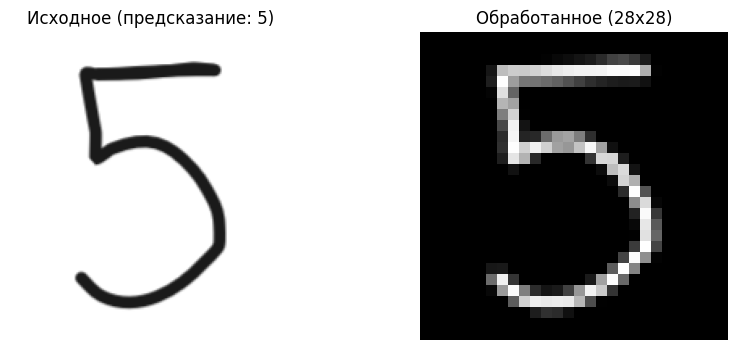

In [96]:
uploaded = files.upload()
for fn in uploaded.keys():
    print(f'Загружен файл: {fn}')
    pred, conf = predict_user_image(final_model, fn, invert=True)
    print(f'Предсказанная цифра: {pred}, уверенность: {conf:.2f}')
    # Отображение исходного изображения
    img = Image.open(fn)
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title(f'Исходное (предсказание: {pred})')
    plt.axis('off')

    # Отображение обработанного изображения (28x28)
    plt.subplot(1, 2, 2)
    plt.imshow(processed.squeeze(), cmap='gray')
    plt.title('Обработанное (28x28)')
    plt.axis('off')
    plt.show()
